a. Load the dataset and perform exploratory data analysis (EDA).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report
)
import joblib
import streamlit as st

In [2]:
df = pd.read_csv("diabetes.csv")

In [3]:
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [4]:
print("Shape of dataset:", df.shape)

Shape of dataset: (768, 9)


b. Examine the features, their types, and summary statistics.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

c. Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

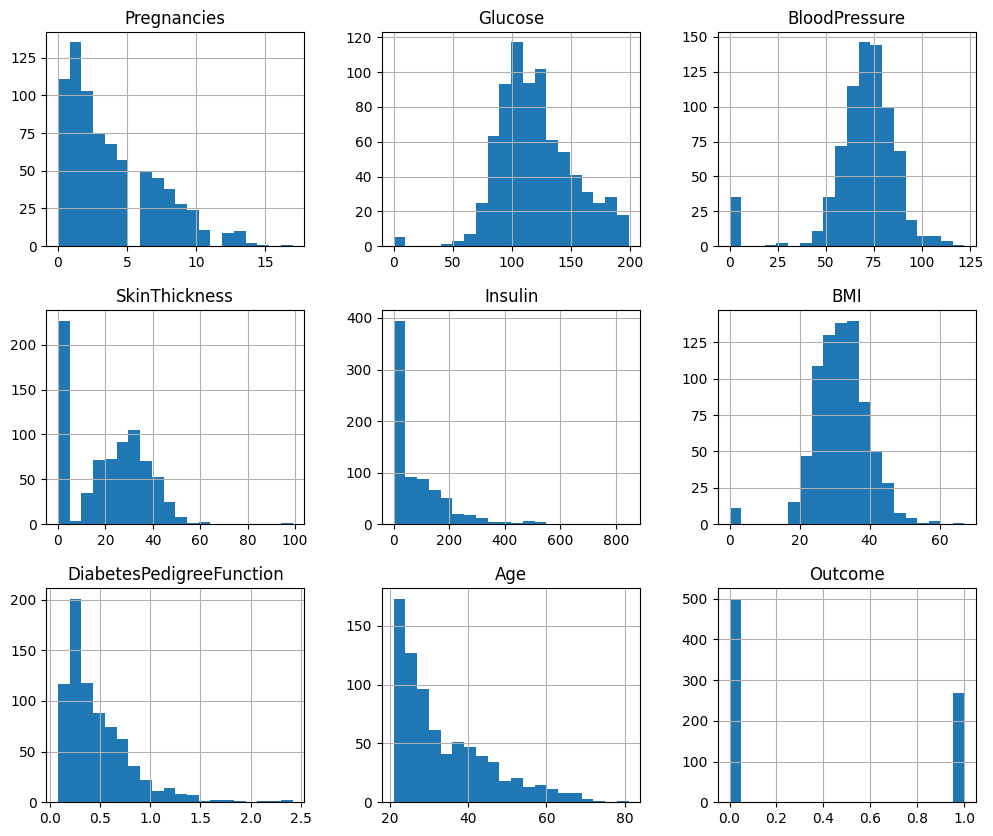

In [8]:
df.hist(figsize = (12,10) ,bins=20)

<Axes: >

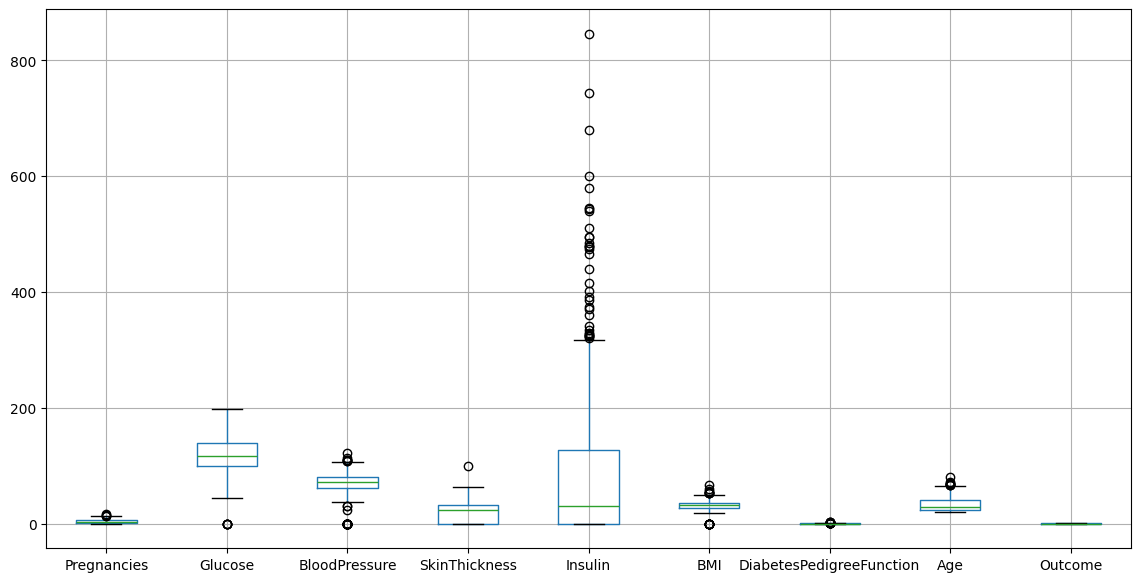

In [9]:
df.boxplot(figsize=(14,7))

Analyze any patterns or correlations observed in the data.

In [10]:
correlation_matrix = df.corr()
print("Correlation Matrix:\n", correlation_matrix)

Correlation Matrix:
                           Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.129459       0.141282      -0.081672   
Glucose                      0.129459  1.000000       0.152590       0.057328   
BloodPressure                0.141282  0.152590       1.000000       0.207371   
SkinThickness               -0.081672  0.057328       0.207371       1.000000   
Insulin                     -0.073535  0.331357       0.088933       0.436783   
BMI                          0.017683  0.221071       0.281805       0.392573   
DiabetesPedigreeFunction    -0.033523  0.137337       0.041265       0.183928   
Age                          0.544341  0.263514       0.239528      -0.113970   
Outcome                      0.221898  0.466581       0.065068       0.074752   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies              -0.073535  0.017683                 -0.033523   
Glucose             

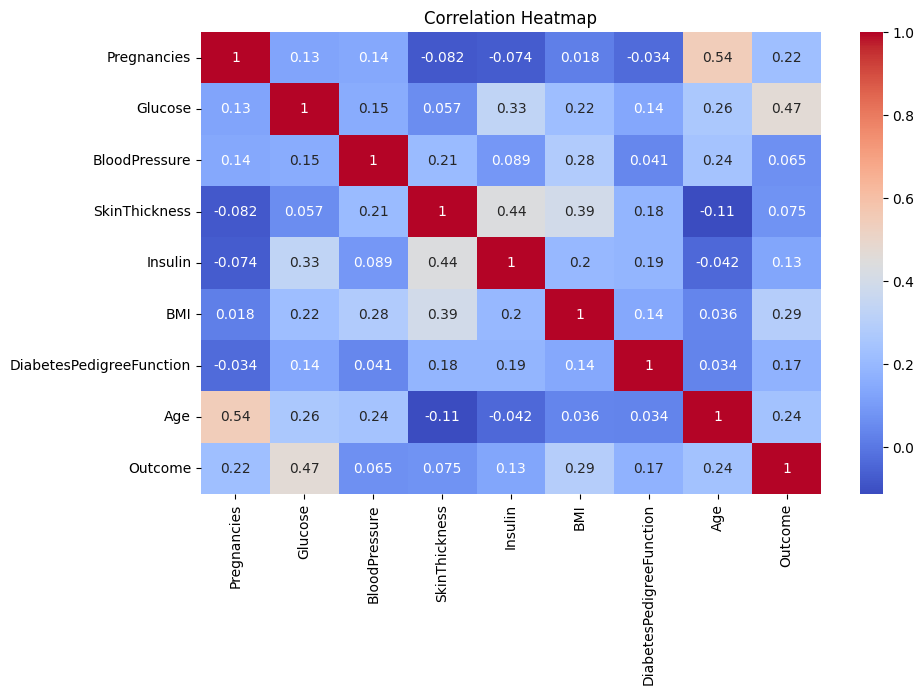

In [11]:
# CORRELATION HEATMAP
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


Glucose vs Outcome = strong positive relationship

BMI vs Outcome = higher BMI increases diabetes probability

Age vs Outcome = older individuals show higher diabetes occurrence

Pregnancies vs Outcome = positive trend

Several features show right-skewed distributions

Glucose, BMI, and Age are strongly associated with diabetes outcome

2. Data Preprocessing:  
a. Handle missing values (e.g., imputation).  
b. Encode categorical variables.


In [12]:
# columns where zero is considered missing
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [13]:
# replacing 0 with NaN
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

In [14]:
print("Missing values before imputation:\n", df.isnull().sum())

Missing values before imputation:
 Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [15]:
for col in cols_with_zero:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\dell\AppData\Local\Temp\ipykernel_16228\2982786776.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\dell\AppData\Local\Temp\ipykernel_16228\2982786776.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

In [16]:
print("Missing values after imputation:\n", df.isnull().sum())

Missing values after imputation:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Outcome is already binary encoded:

0 = non-diabetic

1 = diabetic
no additional encoding is required

3. Model Building:  
a. Build a logistic regression model using appropriate libraries (e.g., scikit-learn).  
b. Train the model using the training data. 


In [17]:
# Features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (614, 8)
Testing set size: (154, 8)


In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [20]:
log_model = LogisticRegression(max_iter=1000)

In [21]:
# train the model
log_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
# Save files
joblib.dump(log_model, "logistic_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

4. Model Evaluation:
a. Evaluate the performance of the model on the testing data using accuracy, precision, recall, F1-score, and ROC-AUC score.
Visualize the ROC curve.


In [22]:


# predictions
y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

# performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC Score:", roc_auc)

# detailed classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.7077922077922078
Precision: 0.6
Recall: 0.5
F1-score: 0.5454545454545454
ROC-AUC Score: 0.812962962962963

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



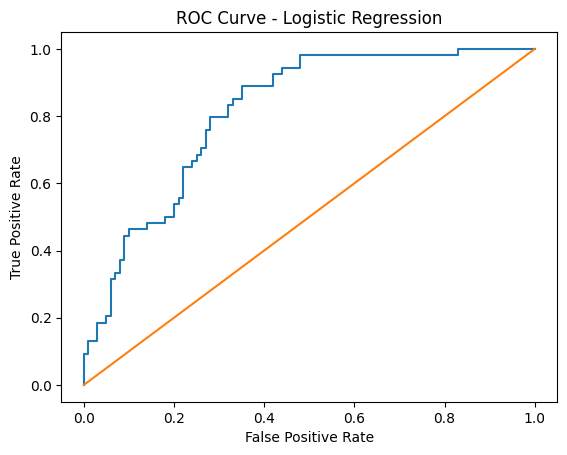

In [23]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.show()


5. Interpretation:
a. Interpret the coefficients of the logistic regression model.
b. Discuss the significance of features in predicting the target variable (survival probability in this case).


In [24]:
# get feature names
feature_names = X.columns

# extract coefficients
coefficients = log_model.coef_[0]

# create a DataFrame for interpretation
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# sort by absolute importance
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

print(coef_df)

                    Feature  Coefficient
1                   Glucose     1.182511
5                       BMI     0.688735
0               Pregnancies     0.377502
6  DiabetesPedigreeFunction     0.233386
7                       Age     0.147798
3             SkinThickness     0.028225
2             BloodPressure    -0.044066
4                   Insulin    -0.066157


Glucose is a strongest predictor and directly linked to blood sugar regulation
BMI reflects obesity, a major diabetes risk factor
Risk increases with age

Pregnancies, DiabetesPedigreeFunction, Insulin are moderate significant feature.

BloodPressure, SkinThickness are least significant feature

Interview Questions:

1. What is the difference between precision and recall?
Precision:
out of all patients predicted as diabetic, how many truly have diabetes?

Recall:
out of all patients who actually have diabetes, how many did the model correctly detect?


2. What is cross-validation, and why is it important in binary classification?

Cross-validation is a model evaluation technique where the dataset is split into multiple subsets (folds). The model is trained on some folds and tested on the remaining fold, and this process is repeated several times. The final performance is the average of all evaluations

cross validation is important in binary classification for better generalization, reduces overfitting,
efficient use of data, model comparision